# 

In [3]:
import vispy
print(vispy.sys_info())

RFBOutputContext()

Platform: Windows-11-10.0.26200-SP0
Python:   3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
NumPy:    2.3.3
Backend:  jupyter_rfb
pyqt4:    None
pyqt5:    None
pyqt6:    ('PyQt6', '6.7.1', '6.7.1')
pyside:   None
pyside2:  None
pyside6:  None
pyglet:   None
glfw:     None
sdl2:     None
wx:       None
egl:      None
osmesa:   None
tkinter:  None
jupyter_rfb: jupyter_rfb
_test:    None

GL version:  '4.6.0 Compatibility Profile Context 23.19.21.11.250530'
MAX_TEXTURE_SIZE: 16384
Extensions: 'GL_EXT_abgr GL_EXT_blend_color GL_EXT_blend_minmax GL_EXT_blend_subtract GL_EXT_copy_texture GL_EXT_texture GL_EXT_texture_object GL_EXT_vertex_array GL_EXT_compiled_vertex_array GL_EXT_subtexture GL_EXT_texture3D GL_EXT_bgra GL_EXT_draw_range_elements GL_EXT_packed_pixels GL_EXT_point_parameters GL_EXT_rescale_normal GL_EXT_separate_specular_color GL_EXT_texture_edge_clamp GL_SGIS_generate_mipmap GL_SGIS_texture_edge_clamp GL_SGIS_texture_lod GL_ARB

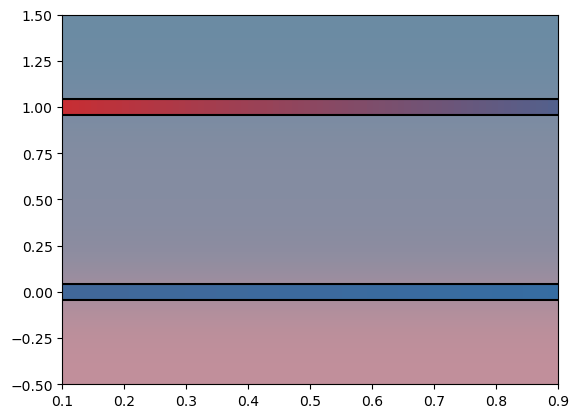

In [119]:
import matplotlib.pyplot as plt 
import matplotlib.colors as mcol
import matplotlib.cm as cm
from matplotlib.collections import LineCollection
import numpy as np
import warnings

def colored_line(x, y, c, ax,stroke=False,stroke_color='black', **lc_kwargs):
    """
    Plot a line with a color specified along the line by a third value.

    It does this by creating a collection of line segments. Each line segment is
    made up of two straight lines each connecting the current (x, y) point to the
    midpoints of the lines connecting the current point with its two neighbors.
    This creates a smooth line with no gaps between the line segments.

    Parameters
    ----------
    x, y : array-like
        The horizontal and vertical coordinates of the data points.
    c : array-like
        The color values, which should be the same size as x and y.
    ax : Axes
        Axis object on which to plot the colored line.
    **lc_kwargs
        Any additional arguments to pass to matplotlib.collections.LineCollection
        constructor. This should not include the array keyword argument because
        that is set to the color argument. If provided, it will be overridden.

    Returns
    -------
    matplotlib.collections.LineCollection
        The generated line collection representing the colored line.
    """
    if "array" in lc_kwargs:
        warnings.warn('The provided "array" keyword argument will be overridden')

    # Default the capstyle to butt so that the line segments smoothly line up
    default_kwargs = {"capstyle": "butt"}
    default_kwargs.update(lc_kwargs)

    # Compute the midpoints of the line segments. Include the first and last points
    # twice so we don't need any special syntax later to handle them.
    x = np.asarray(x)
    y = np.asarray(y)
    x_midpts = np.hstack((x[0], 0.5 * (x[1:] + x[:-1]), x[-1]))
    y_midpts = np.hstack((y[0], 0.5 * (y[1:] + y[:-1]), y[-1]))
    
    
    # Create a line below the main line to create a stroke effect
    if not stroke == False:
        ax.plot(x, y, color=stroke_color, linewidth=lc_kwargs.get('linewidth', 2) + stroke, zorder=1)


    # Determine the start, middle, and end coordinate pair of each line segment.
    # Use the reshape to add an extra dimension so each pair of points is in its
    # own list. Then concatenate them to create:
    # [
    #   [(x1_start, y1_start), (x1_mid, y1_mid), (x1_end, y1_end)],
    #   [(x2_start, y2_start), (x2_mid, y2_mid), (x2_end, y2_end)],
    #   ...
    # ]
    coord_start = np.column_stack((x_midpts[:-1], y_midpts[:-1]))[:, np.newaxis, :]
    coord_mid = np.column_stack((x, y))[:, np.newaxis, :]
    coord_end = np.column_stack((x_midpts[1:], y_midpts[1:]))[:, np.newaxis, :]
    segments = np.concatenate((coord_start, coord_mid, coord_end), axis=1)

    lc = LineCollection(segments, **default_kwargs)
    lc.set_array(c)  # set the colors of each segment

    return ax.add_collection(lc)


cm_hs = mcol.LinearSegmentedColormap.from_list("MyCmapName",["tab:blue","tab:red"])
cm_fg = mcol.LinearSegmentedColormap.from_list("MyCmapName",["xkcd:grey blue","xkcd:grey pink"])
norm_hs = mcol.Normalize(vmin=250, vmax=500)
norm_fg = mcol.Normalize(vmin=200, vmax=250)

fig,ax = plt.subplots()

x = np.linspace(0, 1, 100)
y = 1 * np.ones_like(x)

ax.imshow([[200, 200], [215, 215]],
           cmap=cm_fg,
           extent=[x.min(), x.max(), 0.5, 1.5],
           interpolation='gaussian',
           norm=norm_fg
           )

ax.imshow([[215, 215], [250, 250]],
            cmap=cm_fg,
            extent=[x.min(), x.max(), -0.5, 0.5],
            interpolation='gaussian',
            norm=norm_fg
            
            
)
              
c = np.linspace(500, 300, len(x))
c2 = np.linspace(300, 280, len(x))

line = colored_line(x, y, c, ax, cmap=cm_hs, linewidth=10,stroke=3,stroke_color='black',norm=norm_hs)
y2 = np.zeros_like(x)
line2 = colored_line(x, y2, c2, ax, cmap=cm_hs, linewidth=10,stroke=3,stroke_color='black',norm=norm_hs)
ax.set_aspect("auto")
ax.set_xlim(x.min()+0.1, x.max()-0.1)
ax.axis('on')
plt.show()

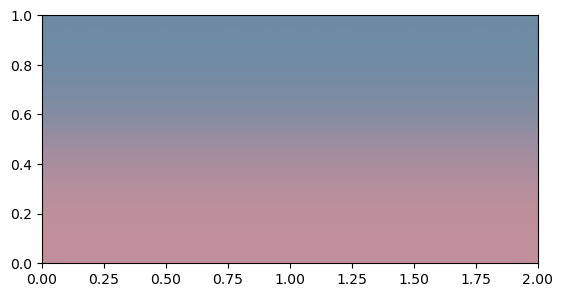

In [127]:
def vertical_gradient_rect(x, y, c, ax, cmap, norm):
    """
    Create a vertical gradient rectangle at the specified x and y coordinates with the given color values, colormap, and normalization.
    
    Parameters
    ----------
    x : array-like
        The x coordinates of the rectangle vertices. Must be of length 2.
    y : array-like
        The y coordinates of the rectangle vertices. Must be of length 2.
    c : array-like
        The values used to color the rectangle. Must be of length 2.
    ax : matplotlib axis
        The axis to plot on.
    cmap : matplotlib colormap
        The colormap to use for coloring the rectangle.
    norm : matplotlib Normalize
        The normalization to apply to the color values.
    """
    
    return ax.imshow(
        [[c[0], c[0]], [c[1], c[1]]], # The color values for the rectangle vertices. 
        cmap=cmap,
        norm=norm,
        interpolation='gaussian', # Smooth and fast interpolation
        extent=[x[0], x[1], y[0], y[1]]  # The extent of the rectangle
    )

fig, ax = plt.subplots()
cm_fg = mcol.LinearSegmentedColormap.from_list("MyCmapName",["xkcd:grey blue","xkcd:grey pink"])
norm_fg = mcol.Normalize(vmin=200, vmax=250)
vertical_gradient_rect([0, 2], [0, 1], [200, 250], ax, cmap=cm_fg, norm=norm_fg)

plt.show()

In [29]:
import matplotlib.pyplot as plt 
import matplotlib.colors as mcol
import matplotlib.cm as cm
from matplotlib.collections import LineCollection
import numpy as np
import warnings

def colored_line(x, y, c, ax,stroke=False,stroke_color='black', **lc_kwargs):
            """
            Plot a line with a color specified along the line by a third value.
            Parameters
            ----------
            x,y : array-like 
                The x and y coordinates of the line points.
            c : array-like
                The values used to color the line. Must be the same length as x and y.
            ax : matplotlib axis
                The axis to plot on.
            stroke : bool, optional
                Whether to add a stroke (outline) to the line for better visibility. Default is False.
            stroke_color : str, optional
                The color of the stroke if stroke is True. Default is 'black'.
            **lc_kwargs : keyword arguments
                Additional keyword arguments passed to LineCollection.
            """ 
            # Based on https://matplotlib.org/stable/gallery/lines_bars_and_markers/multicolored_line.html with modifications for stroke
            
            # Default the capstyle to butt so that the line segments smoothly line up
            default_kwargs = {"capstyle": "butt"}
            default_kwargs.update(lc_kwargs)
            
            # Compute the midpoints of the line segments. Include the first and last points
            # twice so we don't need any special syntax later to handle them.
            x = np.asarray(x)
            y = np.asarray(y)
            x_midpts = np.hstack((x[0], 0.5 * (x[1:] + x[:-1]), x[-1]))
            y_midpts = np.hstack((y[0], 0.5 * (y[1:] + y[:-1]), y[-1]))
            
            # Create a line below the main line to create a stroke effect
            if not stroke == False:
                ax.plot(x, y, color=stroke_color, linewidth=lc_kwargs.get('linewidth', 2) + stroke, zorder=1)        
            
            # Create line segments for the LineCollection. The segments are defined by their start, midpoint, and end coordinates.
            coord_start = np.column_stack((x_midpts[:-1], y_midpts[:-1]))[:, np.newaxis, :]
            coord_mid = np.column_stack((x, y))[:, np.newaxis, :]
            coord_end = np.column_stack((x_midpts[1:], y_midpts[1:]))[:, np.newaxis, :]
            segments = np.concatenate((coord_start, coord_mid, coord_end), axis=1)

            lc = LineCollection(segments, **default_kwargs)
            lc.set_array(c)  # set the colors of each segment

            return ax.add_collection(lc)

def onclick(event):
    print(f"Clicked at coordinates: ({event.xdata}, {event.ydata})")

%matplotlib qt
ax, fig = plt.subplots()

cm_hs = mcol.LinearSegmentedColormap.from_list("MyCmapName",["tab:blue","tab:red"])
norm_hs = mcol.Normalize(vmin=250, vmax=500)

x = np.linspace(0, 1, 100)
y = 1 * np.ones_like(x)
c = np.linspace(250, 500, len(x))

colored_line(x, y, c, plt.gca(), stroke=8, stroke_color='black', linewidth=4, cmap=cm_hs, norm=norm_hs)

cid = ax.canvas.mpl_connect('button_press_event', onclick)
plt.show()

In [ ]:
import matplotlib.pyplot as plt 
import matplotlib.colors as mcol
import matplotlib.cm as cm
from matplotlib.collections import LineCollection
import numpy as np


ax, fig = plt.subplots()

